In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
zip_path = "archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

In [ ]:
yes_count = len(os.listdir(os.path.join(dataset_path, "yes")))
no_count = len(os.listdir(os.path.join(dataset_path, "no")))

print("Tumor Images :", yes_count)
print("No Tumor Images :", no_count)

Tumor Images : 155
No Tumor Images : 98


Display sample Images

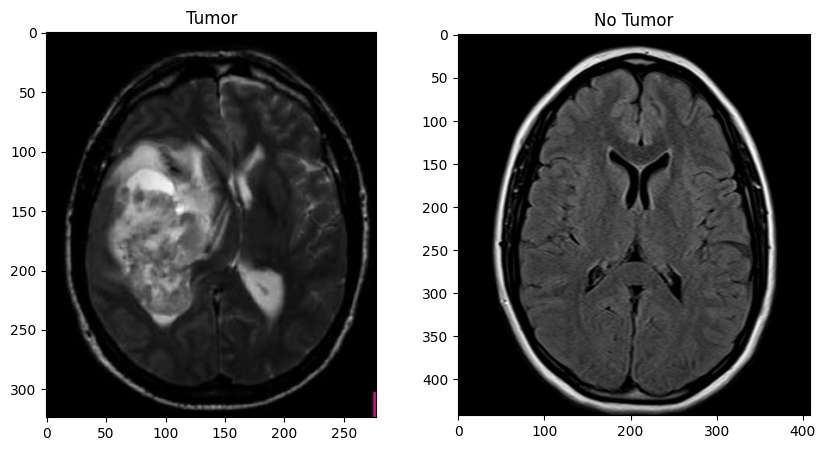

In [ ]:
import cv2

plt.figure(figsize=(10,5))

tumor_img = os.listdir(os.path.join(dataset_path,"yes"))[0]
normal_img = os.listdir(os.path.join(dataset_path,"no"))[0]

img1 = cv2.imread(os.path.join(dataset_path,"yes",tumor_img))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(os.path.join(dataset_path,"no",normal_img))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Tumor")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("No Tumor")

plt.show()

Create Train & Validation Data

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


TensorFlow automatically divided the dataset into:

80% Training Data

20% Validation Data

Check Labels

In [ ]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


Build CNN Model

In [ ]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Train Model


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6946 - loss: 0.6129 - val_accuracy: 0.7400 - val_loss: 0.5378
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 891ms/step - accuracy: 0.7931 - loss: 0.4797 - val_accuracy: 0.7600 - val_loss: 0.5947
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 951ms/step - accuracy: 0.8276 - loss: 0.4781 - val_accuracy: 0.7400 - val_loss: 0.5727
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8374 - loss: 0.4190 - val_accuracy: 0.7600 - val_loss: 0.4985
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 869ms/step - accuracy: 0.8424 - loss: 0.3592 - val_accuracy: 0.7600 - val_loss: 0.5842
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8522 - loss: 0.3399 - val_accuracy: 0.8000 - val_loss: 0.5200
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 935ms/step - accuracy: 0.9064 - loss: 0.2746 - val_accuracy: 0.8000 - val_loss: 0.4556
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9212 - loss: 0.2123 - val_accuracy: 0.8200 - val_loss: 0.3938
Epoc

Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8200 - loss: 0.3938
Validation Accuracy : 0.8199999928474426


Plot Accuracy

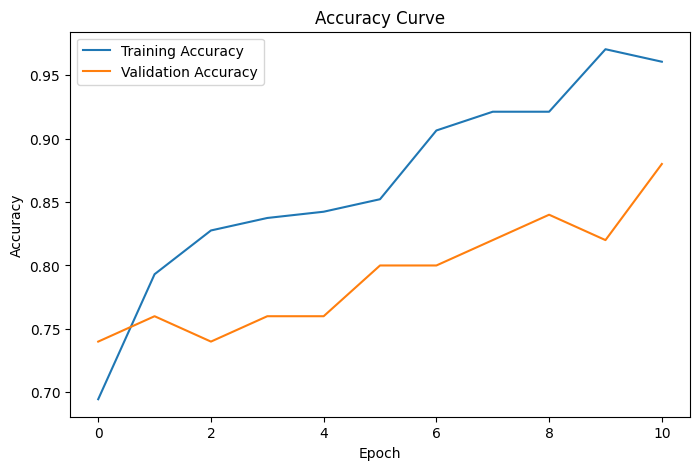

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

Plot Loss

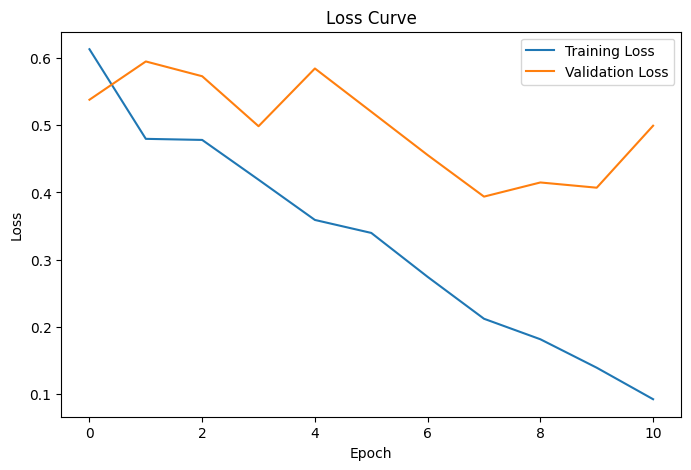

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

Save Model

In [ ]:
model.save("brain_tumor_cnn.h5")

print("Model Saved")

Model Saved


Predict on New MRI Image

In [ ]:
from tensorflow.keras.preprocessing import image

# Corrected path to an existing image file
img_path = "/content/3c7b18a8-c266-455c-b552-dd660d9fac50.jpg.jpeg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
[[0.8657029]]


In [ ]:
if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

Brain Tumor Detected


In Machine learning

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

images = []
labels = []

In [ ]:
tumor_folder = os.path.join(dataset_path,"yes")

for img_name in os.listdir(tumor_folder):

    img_path = os.path.join(
        tumor_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(1)

In [ ]:
normal_folder = os.path.join(dataset_path,"no")

for img_name in os.listdir(normal_folder):

    img_path = os.path.join(
        normal_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(0)

In [ ]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(253, 128, 128, 3)
(253,)


In [ ]:
X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_ml = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_ml = X_test.reshape(
    X_test.shape[0],
    -1
)

print(X_train_ml.shape)

(202, 49152)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_ml,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_ml = rf.predict(
    X_test_ml
)

In [ ]:
ml_accuracy = accuracy_score(
    y_test,
    y_pred_ml
)

print(
    "Machine Learning Accuracy:",
    ml_accuracy
)

Machine Learning Accuracy: 0.7843137254901961


In [ ]:
cnn = Sequential()

cnn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(Flatten())

cnn.add(Dense(
    128,
    activation='relu'
))

cnn.add(
    Dropout(0.5)
)

cnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6087 - loss: 0.8683 - val_accuracy: 0.1951 - val_loss: 0.7954
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 717ms/step - accuracy: 0.6273 - loss: 0.6665 - val_accuracy: 0.7805 - val_loss: 0.5601
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7516 - loss: 0.5426 - val_accuracy: 0.7561 - val_loss: 0.5579
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 839ms/step - accuracy: 0.7329 - loss: 0.5530 - val_accuracy: 0.8049 - val_loss: 0.5064
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 718ms/step - accuracy: 0.7826 - loss: 0.4735 - val_accuracy: 0.8049 - val_loss: 0.5489
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 903ms/step - accuracy: 0.7950 - loss: 0.4763 - val_accuracy: 0.7317 - val_loss: 0.7023
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7578 - loss: 0.5237 - val_accuracy: 0.7317 - val_loss: 0.6612
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7764 - loss: 0.5390 - val_accuracy: 0.8049 - val_loss: 0.5584
Epo

In [ ]:
loss, dl_accuracy = cnn.evaluate(
    X_test,
    y_test
)

print(
    "Deep Learning Accuracy:",
    dl_accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.8039 - loss: 0.5184
Deep Learning Accuracy: 0.8039215803146362


In [ ]:
print("\nMODEL COMPARISON")
print("--------------------------")
print("Random Forest :", ml_accuracy)
print("CNN           :", dl_accuracy)


MODEL COMPARISON
--------------------------
Random Forest : 0.7843137254901961
CNN           : 0.8039215803146362


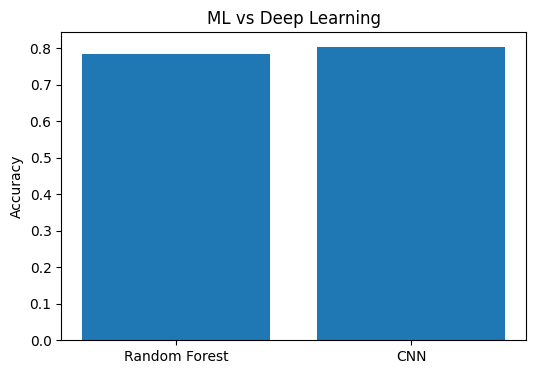

In [ ]:
models = [
    "Random Forest",
    "CNN"
]

scores = [
    ml_accuracy,
    dl_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")
plt.title("ML vs Deep Learning")

plt.show()